# HMM Activity Recognition
## Modeling Human Activity States Using Hidden Markov Models

**Pipeline**
1. Data Loading & Preprocessing
2. Feature Extraction (Time & Frequency Domain)
3. HMM Training — Baum–Welch with log-likelihood convergence
4. Viterbi Decoding — custom NumPy implementation
5. Visualizations — transition matrix, emission means, decoded sequences
6. Evaluation on Unseen Data — sensitivity, specificity, accuracy
7. Analysis & Reflection

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.fft import fft, fftfreq
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score
from sklearn.model_selection import train_test_split
from hmmlearn import hmm
from collections import Counter, defaultdict
import os, warnings

warnings.filterwarnings('ignore')
np.random.seed(42)
plt.rcParams.update({'figure.dpi': 100, 'font.size': 11})

print('All libraries imported successfully.')

All libraries imported successfully.


## Data Overview

| Member | Device | App | Actual Sampling Rate |
|---|---|---|---|
| Person A | Google Pixel 6 (Android) | Sensor Logger 1.54.1 | ~56 Hz |
| Person B | iPhone 11 (iOS) | Sensor Logger 1.54 | ~99.5 Hz |

Both devices were resampled to **100 Hz** using linear interpolation. Only the `Accelerometer.csv` and `gyroscope.csv`
file from each session folder is used to ensure consistency across both devices.

**Window size:** 2.0 s (200 samples @ 100 Hz) | **Overlap:** 50% (step = 100 samples)

In [ ]:
# ─── PATHS ───────────────────────────────────────────────────────────────────
DATA_DIR    = '../data/train/'   # 50 labelled sessions (25 per person)
TEST_DIR    = '../data/test/'    # 13 unseen sessions recorded after training
OUTPUTS_DIR = '../outputs/'      # all saved plots go here

os.makedirs(OUTPUTS_DIR, exist_ok=True)

# ─── ACTIVITIES ──────────────────────────────────────────────────────────────
ACTIVITIES = ['standing', 'walking', 'jumping', 'still']
N_STATES   = len(ACTIVITIES)

ACTIVITY_COLORS = {
    'standing': '#2196F3',
    'walking' : '#4CAF50',
    'jumping' : '#F44336',
    'still'   : '#9C27B0',
}

# ─── SAMPLING & WINDOWING ────────────────────────────────────────────────────
# Both phones requested sampleRateMs=10 (100 Hz) in Sensor Logger,
# but Android does not guarantee exact delivery rates:
#
# Harmonisation notes:
#   Phone A (person A): Google Pixel 6, Android 36, Sensor Logger 1.54.1
#                       Requested 100 Hz → actual delivery ~56 Hz
#   Phone B (person B): iPhone 11, iOS 26.2.1, Sensor Logger 1.54
#                       Requested 100 Hz → actual delivery ~100 Hz
#   Chosen target rate : 100 Hz
#
# The loader resamples both phones to TARGET_FS via linear interpolation
# (np.interp over seconds_elapsed), so all windows are uniform at 100 Hz.
# Upsampling the Pixel 6 from 56 → 100 Hz introduces mild interpolation
# smoothing but does not change the activity-level features meaningfully.

TARGET_FS     = 100     # Hz — common resampling target
WINDOW_SECS   = 2.0     # seconds per window
OVERLAP_RATIO = 0.5     # 50 % overlap between consecutive windows

WINDOW_SAMPLES = int(WINDOW_SECS * TARGET_FS)
STEP_SAMPLES   = int(WINDOW_SAMPLES * (1 - OVERLAP_RATIO))

print(f'Target sampling rate : {TARGET_FS} Hz')
print(f'Window size          : {WINDOW_SECS}s  =  {WINDOW_SAMPLES} samples')
print(f'Step size            : {STEP_SAMPLES} samples  ({int(OVERLAP_RATIO*100)}% overlap)')
print()
print('Window size rationale:')
print(f'  At {TARGET_FS} Hz, a {WINDOW_SECS}s window gives {WINDOW_SAMPLES} samples —')
print('  enough for stable FFT resolution (freq resolution = 1/window = 0.5 Hz)')
print('  while remaining short enough to capture transient bursts like jumps.')
print()
print(f'Output folder: {OUTPUTS_DIR}')

Target sampling rate : 100 Hz
Window size          : 2.0s  =  200 samples
Step size            : 100 samples  (50% overlap)

Window size rationale:
  At 100 Hz, a 2.0s window gives 200 samples —
  enough for stable FFT resolution (freq resolution = 1/window = 0.5 Hz)
  while remaining short enough to capture transient bursts like jumps.

Output folder: ../outputs/


---
## Section 1 — Data Loading & Preprocessing

### Folder structure
```
data/
  train/                                  ← 50 sessions total (25 per person)
    standing_A_01-2026-03-03_15-00-00/    ← person A sessions
    standing_A_02-2026-03-03_15-03-00/
    walking_A_01-2026-03-03_15-10-00/
    jumping_A_01-2026-03-03_15-20-00/
    still_A_01-2026-03-03_15-30-00/
    ...
    standing_B_01-2026-03-03_11-11-18/    ← person B sessions (already here)
    walking_B_01-2026-03-03_11-18-22/
    jumping_B_01-2026-03-03_11-24-51/
    still_B_01-2026-03-02_14-20-00/
    ...

  test/                                   ← 12 unseen sessions (3 per activity)
    standing_test_01-2026-03-04_.../      ← recorded AFTER training is done
    walking_test_01-2026-03-04_.../
    jumping_test_01-2026-03-04_.../
    still_test_01-2026-03-04_.../
    ...
```

**Naming rule**: folder must start with `{activity}_` — the rest is kept from Sensor Logger.  
Person A uses `_A_`, person B uses `_B_`, test sessions use `_test_` (or any suffix that isn't A/B).

### Why train/test split by folder (not randomly)?
Splitting at the **session level** is stricter and more realistic — the model never sees any
windows from a test session during training. A random window-level split would leak information
because windows from the same session have correlated signals.

### Files used per session
| File | Used | Contents |
|---|---|---|
| `Accelerometer.csv` | **Yes** | `time` (ns), `seconds_elapsed`, `z`, `y`, `x` |
| `Gyroscope.csv` | **Yes** | `time` (ns), `seconds_elapsed`, `z`, `y`, `x` |
| `AccelerometerUncalibrated.csv` | No | raw hardware values |
| `GyroscopeUncalibrated.csv` | No | raw hardware values |
| `Annotation.csv` | No | manual event markers |
| `Metadata.csv` | No | device info, sample rate |

In [ ]:
def _load_sensor_csv(filepath, target_fs=TARGET_FS):
    '''
    Load one Sensor Logger CSV (Accelerometer.csv or Gyroscope.csv).

    Sensor Logger column layout:
        time (ns epoch), seconds_elapsed, z, y, x

    Returns a DataFrame with columns [time, x, y, z] resampled to target_fs.
    '''
    df = pd.read_csv(filepath)
    df.columns = [c.strip().lower() for c in df.columns]

    # seconds_elapsed is the clean relative time axis
    t = df['seconds_elapsed'].values.astype(float)

    # axis columns
    x = df['x'].values.astype(float)
    y = df['y'].values.astype(float)
    z = df['z'].values.astype(float)

    # resample to target_fs via linear interpolation
    duration = t[-1] - t[0]
    if duration <= 0:
        duration = len(t) / target_fs
    n_out = max(2, int(duration * target_fs))
    t_new = np.linspace(t[0], t[-1], n_out)

    return pd.DataFrame({
        'time': t_new - t_new[0],
        'x'   : np.interp(t_new, t, x),
        'y'   : np.interp(t_new, t, y),
        'z'   : np.interp(t_new, t, z),
    })


def infer_activity(folder_name):
    '''
    Infer activity label from a Sensor Logger folder name.

    Naming pattern: {activity}_{person}_{num}-{YYYY-MM-DD}_{HH-MM-SS}
    e.g.  still_B_01-2026-03-02_14-20-00  →  'still'
          walking_A_03-2026-03-02_15-10-00 →  'walking'
    '''
    base = os.path.basename(folder_name).lower()
    for act in ACTIVITIES:
        if base.startswith(act + '_') or base.startswith(act + '-'):
            return act
    return 'unknown'


def load_session_folder(folder_path, target_fs=TARGET_FS):
    '''
    Load one Sensor Logger recording folder.

    Reads Accelerometer.csv → acc_x, acc_y, acc_z
    Reads Gyroscope.csv    → gyr_x, gyr_y, gyr_z
    Merges both onto the accelerometer time axis.

    Returns a DataFrame with columns:
        time, acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z
    '''
    acc_path = os.path.join(folder_path, 'Accelerometer.csv')
    gyr_path = os.path.join(folder_path, 'Gyroscope.csv')

    if not os.path.exists(acc_path):
        raise FileNotFoundError(f'Accelerometer.csv not found in {folder_path}')

    acc = _load_sensor_csv(acc_path, target_fs)

    if os.path.exists(gyr_path):
        gyr = _load_sensor_csv(gyr_path, target_fs)
        # interpolate gyroscope onto the accelerometer time axis
        gyr_x = np.interp(acc['time'].values, gyr['time'].values, gyr['x'].values)
        gyr_y = np.interp(acc['time'].values, gyr['time'].values, gyr['y'].values)
        gyr_z = np.interp(acc['time'].values, gyr['time'].values, gyr['z'].values)
    else:
        gyr_x = gyr_y = gyr_z = np.zeros(len(acc))

    return pd.DataFrame({
        'time' : acc['time'].values,
        'acc_x': acc['x'].values,
        'acc_y': acc['y'].values,
        'acc_z': acc['z'].values,
        'gyr_x': gyr_x,
        'gyr_y': gyr_y,
        'gyr_z': gyr_z,
    })


def load_all_sessions(directory):
    '''
    Scan a directory for Sensor Logger session folders and load them all.

    A valid session folder contains at least an Accelerometer.csv.

    Returns list of (df, label, folder_path) tuples.
    '''
    if not os.path.isdir(directory):
        print(f'  [WARN] Directory not found: {directory}')
        return []

    # find all subfolders that contain Accelerometer.csv
    session_folders = sorted([
        os.path.join(directory, name)
        for name in os.listdir(directory)
        if os.path.isdir(os.path.join(directory, name))
        and os.path.exists(os.path.join(directory, name, 'Accelerometer.csv'))
    ])

    if not session_folders:
        print(f'  [WARN] No Sensor Logger session folders found in {directory}')
        print('         Each session must be a subfolder containing Accelerometer.csv')
        return []

    data = []
    for folder in session_folders:
        folder_name = os.path.basename(folder)
        label = infer_activity(folder_name)

        if label == 'unknown':
            print(f'  [SKIP] cannot infer activity from folder: {folder_name}')
            continue

        try:
            df = load_session_folder(folder, TARGET_FS)
            df['label'] = label
            dur = df['time'].iloc[-1]
            n   = len(df)
            print(f'  [OK]  {folder_name:<50s}  {label:<10}  {n:5d} samples  {dur:.1f}s')
            data.append((df, label, folder))
        except Exception as e:
            print(f'  [ERR] {folder_name}: {e}')

    return data


print('Sensor Logger loader functions defined.')
print()
print('Expected folder pattern: {activity}_{person}_{num}-{YYYY-MM-DD}_{HH-MM-SS}')
print('  e.g.  still_B_01-2026-03-02_14-20-00')

Sensor Logger loader functions defined.

Expected folder pattern: {activity}_{person}_{num}-{YYYY-MM-DD}_{HH-MM-SS}
  e.g.  still_B_01-2026-03-02_14-20-00


In [ ]:
print('Loading training data...\n')
all_data = load_all_sessions(DATA_DIR)

if not all_data:
    print('\n  No session folders found. Place Sensor Logger exports in:', DATA_DIR)
    print('  Each folder must be named starting with the activity:')
    print('    still_B_01-2026-03-02_14-20-00/')
    print('    walking_A_02-2026-03-02_15-00-00/')
else:
    counts    = {a: 0   for a in ACTIVITIES}
    durations = {a: 0.0 for a in ACTIVITIES}
    for df, label, _ in all_data:
        counts[label]    += 1
        durations[label] += df['time'].iloc[-1]   # last timestamp = total duration

    print()
    print('── Dataset Summary ───────────────────────────────────────────────')
    print(f'{"Activity":<12} {"Sessions":>9} {"Total Duration":>16}  {"Min req":>12}')
    print('-' * 54)
    for act in ACTIVITIES:
        status = 'OK' if durations[act] >= 90 else 'need >= 90s total'
        print(f'{act:<12} {counts[act]:>9}    {durations[act]:>8.1f}s        {status}')
    print()
    print(f'Total sessions: {len(all_data)}')

Loading training data...

  [OK]  jumping_A_01-2026-03-03_21-21-56                    jumping       772 samples  7.7s
  [OK]  jumping_A_02-2026-03-03_21-22-26                    jumping       817 samples  8.2s
  [OK]  jumping_A_03-2026-03-03_21-22-38                    jumping       719 samples  7.2s
  [OK]  jumping_A_04-2026-03-03_21-23-08                    jumping       745 samples  7.5s
  [OK]  jumping_A_05-2026-03-03_21-23-17                    jumping       770 samples  7.7s
  [OK]  jumping_A_06-2026-03-03_21-24-55                    jumping       797 samples  8.0s
  [OK]  jumping_B_01-2026-03-03_11-24-51                    jumping       966 samples  9.7s
  [OK]  jumping_B_02-2026-03-03_11-25-07                    jumping       859 samples  8.6s
  [OK]  jumping_B_03-2026-03-03_11-25-20                    jumping       888 samples  8.9s
  [OK]  jumping_B_04-2026-03-03_11-25-36                    jumping       877 samples  8.8s
  [OK]  jumping_B_05-2026-03-03_11-25-52              

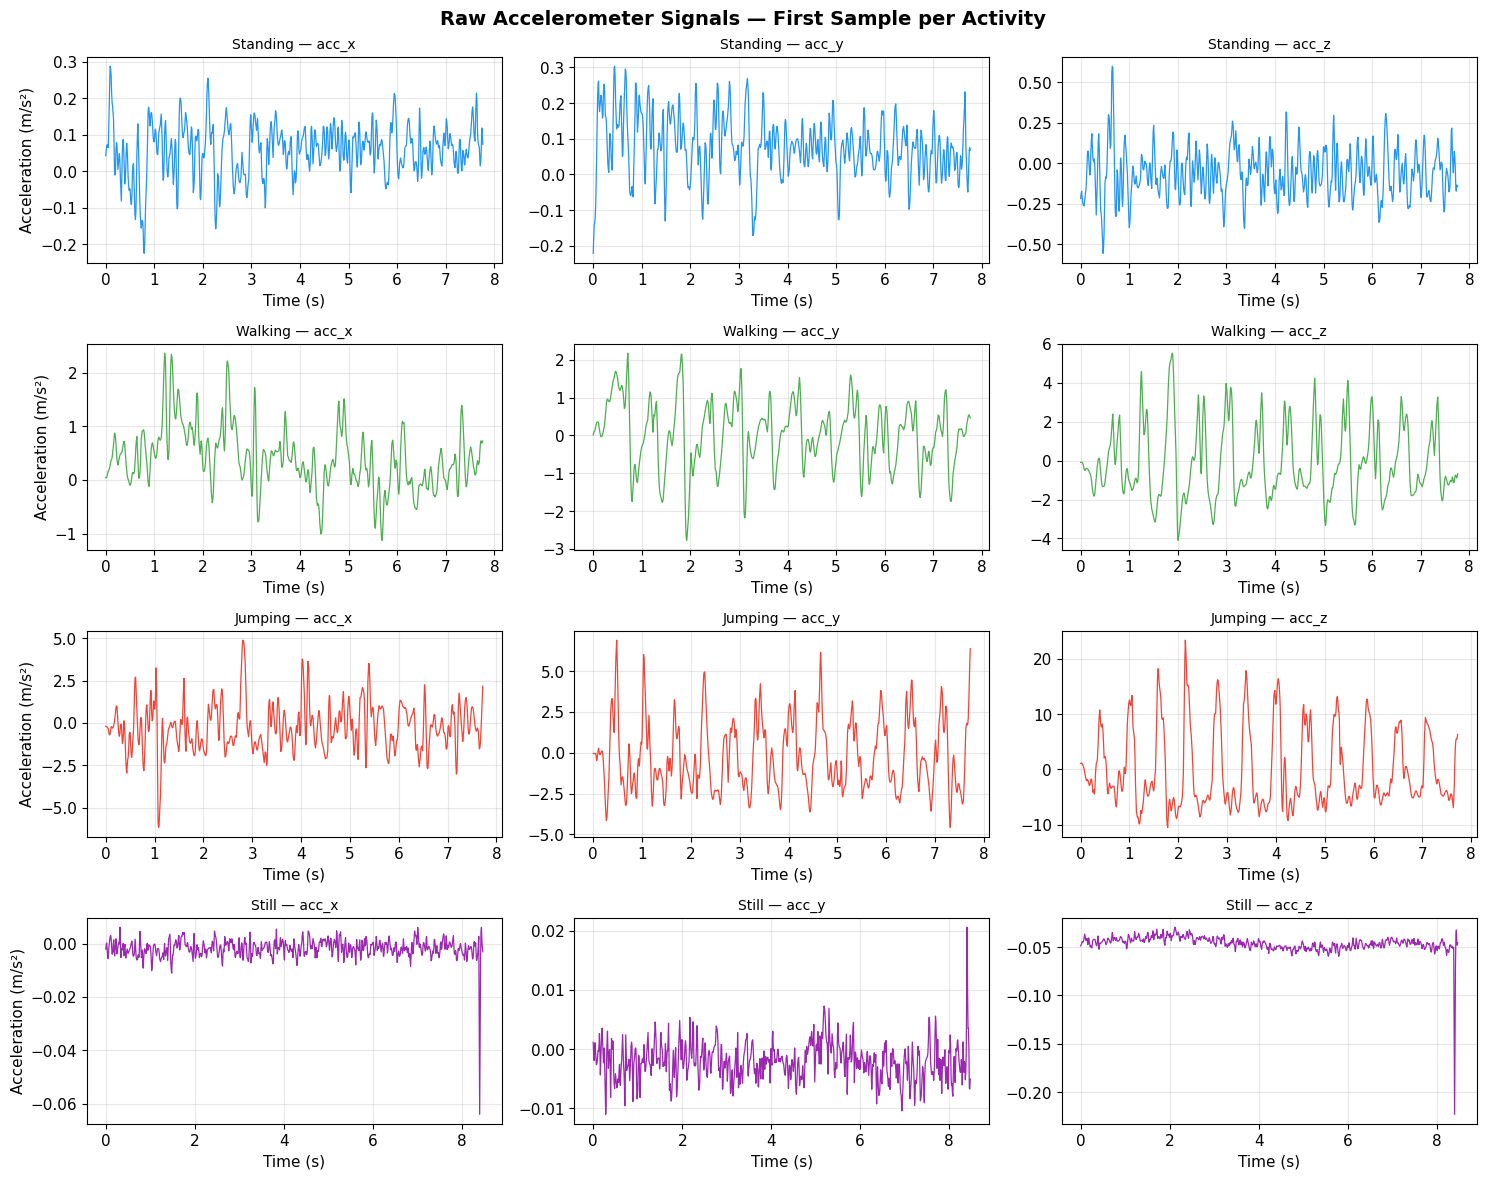

Saved: ../outputs/raw_signals.png


In [ ]:
# Visualise one raw accelerometer recording per activity
fig, axes = plt.subplots(len(ACTIVITIES), 3, figsize=(15, 3 * len(ACTIVITIES)))
fig.suptitle('Raw Accelerometer Signals — First Sample per Activity', fontsize=14, fontweight='bold')

for row, activity in enumerate(ACTIVITIES):
    samples = [(df, lbl, f) for df, lbl, f in all_data if lbl == activity]
    color   = ACTIVITY_COLORS[activity]

    if not samples:
        for col in range(3):
            axes[row, col].text(0.5, 0.5, f'No {activity} data', ha='center',
                                transform=axes[row, col].transAxes)
        continue

    df = samples[0][0]
    t  = df['time'].values

    for col, axis_name in enumerate(['x', 'y', 'z']):
        ax = axes[row, col]
        ax.plot(t, df[f'acc_{axis_name}'].values, color=color, linewidth=0.9)
        ax.set_title(f'{activity.capitalize()} — acc_{axis_name}', fontsize=10)
        ax.set_xlabel('Time (s)')
        if col == 0:
            ax.set_ylabel('Acceleration (m/s²)')
        ax.grid(True, alpha=0.3)

plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'raw_signals.png')
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

**Figure 1 — Raw Accelerometer Signals.**  
> Each row shows one representative session per activity (acc_x, acc_y, acc_z).  
> Jumping produces large-amplitude bursts across all axes. Still is nearly flat.  
> Standing and walking show similar gravity-axis offset but differ in oscillation frequency.

---
## Section 2 — Feature Extraction

Each time window of `WINDOW_SECS` seconds produces one feature vector.

| Feature | Domain | Justification |
|---|---|---|
| Mean (6 channels) | Time | Average orientation/bias per axis |
| Std dev (6 channels) | Time | Variability — high for jumping, low for still |
| RMS (6 channels) | Time | Signal energy per axis |
| Signal Magnitude Area (SMA) | Time | Single scalar for overall body motion intensity |
| acc_x / acc_y correlation | Time | Directional coupling differs across activities |
| Dominant frequency | Frequency | Walking ≈ 1–2 Hz; still ≈ 0 Hz; jumping ≈ 2–3 Hz |
| Spectral energy | Frequency | Total power across frequencies |
| Spectral entropy | Frequency | Randomness of spectrum — periodic vs. aperiodic |

**Normalisation**: Z-score (`StandardScaler`) is fitted on the training set only and applied to
all data. This prevents features with large absolute magnitudes from dominating those with small
values (e.g., raw acceleration vs. correlation ∈ [−1, 1]).

In [ ]:
SIGNAL_COLS = ['acc_x', 'acc_y', 'acc_z', 'gyr_x', 'gyr_y', 'gyr_z']


def compute_time_features(window):
    '''
    Time-domain features from a (W, 6) window array.
    Columns: acc_x, acc_y, acc_z, gyr_x, gyr_y, gyr_z
    '''
    acc = window[:, :3]
    features = []

    # Per channel: mean, std, RMS  (6 channels × 3 = 18 features)
    for ch in range(6):
        x = window[:, ch]
        features.append(float(np.mean(x)))
        features.append(float(np.std(x)))
        features.append(float(np.sqrt(np.mean(x ** 2))))   # RMS

    # Signal Magnitude Area — accelerometer only  (1 feature)
    sma = float(np.mean(np.abs(acc[:, 0]) + np.abs(acc[:, 1]) + np.abs(acc[:, 2])))
    features.append(sma)

    # Pearson correlation acc_x / acc_y  (1 feature)
    if np.std(acc[:, 0]) > 1e-8 and np.std(acc[:, 1]) > 1e-8:
        corr = float(np.corrcoef(acc[:, 0], acc[:, 1])[0, 1])
    else:
        corr = 0.0
    features.append(corr)

    return np.array(features, dtype=np.float64)   # shape: (20,)


def compute_freq_features(window, fs=TARGET_FS):
    '''
    Frequency-domain features via FFT on the accelerometer magnitude.
    '''
    acc = window[:, :3]
    mag = np.sqrt(np.sum(acc ** 2, axis=1))   # acceleration magnitude

    N  = len(mag)
    yf = np.abs(fft(mag))[:N // 2]
    xf = fftfreq(N, d=1.0 / fs)[:N // 2]

    # Dominant frequency — ignore DC (index 0)
    yf_no_dc  = yf.copy()
    yf_no_dc[0] = 0
    dom_freq  = float(xf[np.argmax(yf_no_dc)])

    # Spectral energy
    spec_energy = float(np.sum(yf ** 2) / N)

    # Spectral entropy — measures randomness of power distribution
    psd   = yf / (np.sum(yf) + 1e-12)
    s_ent = float(-np.sum(psd * np.log(psd + 1e-12)))

    return np.array([dom_freq, spec_energy, s_ent], dtype=np.float64)   # shape: (3,)


def extract_features(df):
    '''
    Slide a window over a sensor DataFrame and return an (n_windows, n_features) array.
    '''
    data    = df[SIGNAL_COLS].values
    vectors = []
    for start in range(0, len(data) - WINDOW_SAMPLES + 1, STEP_SAMPLES):
        w  = data[start : start + WINDOW_SAMPLES]
        tf = compute_time_features(w)
        ff = compute_freq_features(w)
        vectors.append(np.concatenate([tf, ff]))
    return np.array(vectors) if vectors else np.empty((0, 23))


N_TIME_FEATS = 20
N_FREQ_FEATS = 3
N_FEATURES   = N_TIME_FEATS + N_FREQ_FEATS

print(f'Features per window: {N_FEATURES}  ({N_TIME_FEATS} time-domain + {N_FREQ_FEATS} frequency-domain)')

Features per window: 23  (20 time-domain + 3 frequency-domain)


In [ ]:
print('Extracting features from all training sessions...\n')

all_feats_raw = []
for df, label, fpath in all_data:
    feats = extract_features(df)
    if len(feats) == 0:
        print(f'  [WARN] {os.path.basename(fpath)}: too short to window, skipped')
        continue
    all_feats_raw.append((feats, label, fpath))
    print(f'  {os.path.basename(fpath):<50s}  {label:<10}  {feats.shape[0]:3d} windows')

# ── Fit Z-score scaler on training data only ──────────────────────────────────
X_all = np.vstack([f for f, _, _ in all_feats_raw])
y_all = np.concatenate([[lbl] * len(f) for f, lbl, _ in all_feats_raw])

scaler       = StandardScaler()
X_all_scaled = scaler.fit_transform(X_all)

print(f'\nTotal windows : {X_all_scaled.shape[0]}')
print(f'Feature shape : {X_all_scaled.shape}')

# ── Per-activity window count ──────────────────────────────────────────────────
print()
print('── Windows per activity ──────────────────────────────────────────────')
for act in ACTIVITIES:
    n = (y_all == act).sum()
    print(f'  {act:<12}  {n:4d} windows')

Extracting features from all training sessions...

  jumping_A_01-2026-03-03_21-21-56                    jumping       6 windows
  jumping_A_02-2026-03-03_21-22-26                    jumping       7 windows
  jumping_A_03-2026-03-03_21-22-38                    jumping       6 windows
  jumping_A_04-2026-03-03_21-23-08                    jumping       6 windows
  jumping_A_05-2026-03-03_21-23-17                    jumping       6 windows
  jumping_A_06-2026-03-03_21-24-55                    jumping       6 windows
  jumping_B_01-2026-03-03_11-24-51                    jumping       8 windows
  jumping_B_02-2026-03-03_11-25-07                    jumping       7 windows
  jumping_B_03-2026-03-03_11-25-20                    jumping       7 windows
  jumping_B_04-2026-03-03_11-25-36                    jumping       7 windows
  jumping_B_05-2026-03-03_11-25-52                    jumping       7 windows
  jumping_B_06-2026-03-03_11-26-12                    jumping       8 windows
  standing_A_

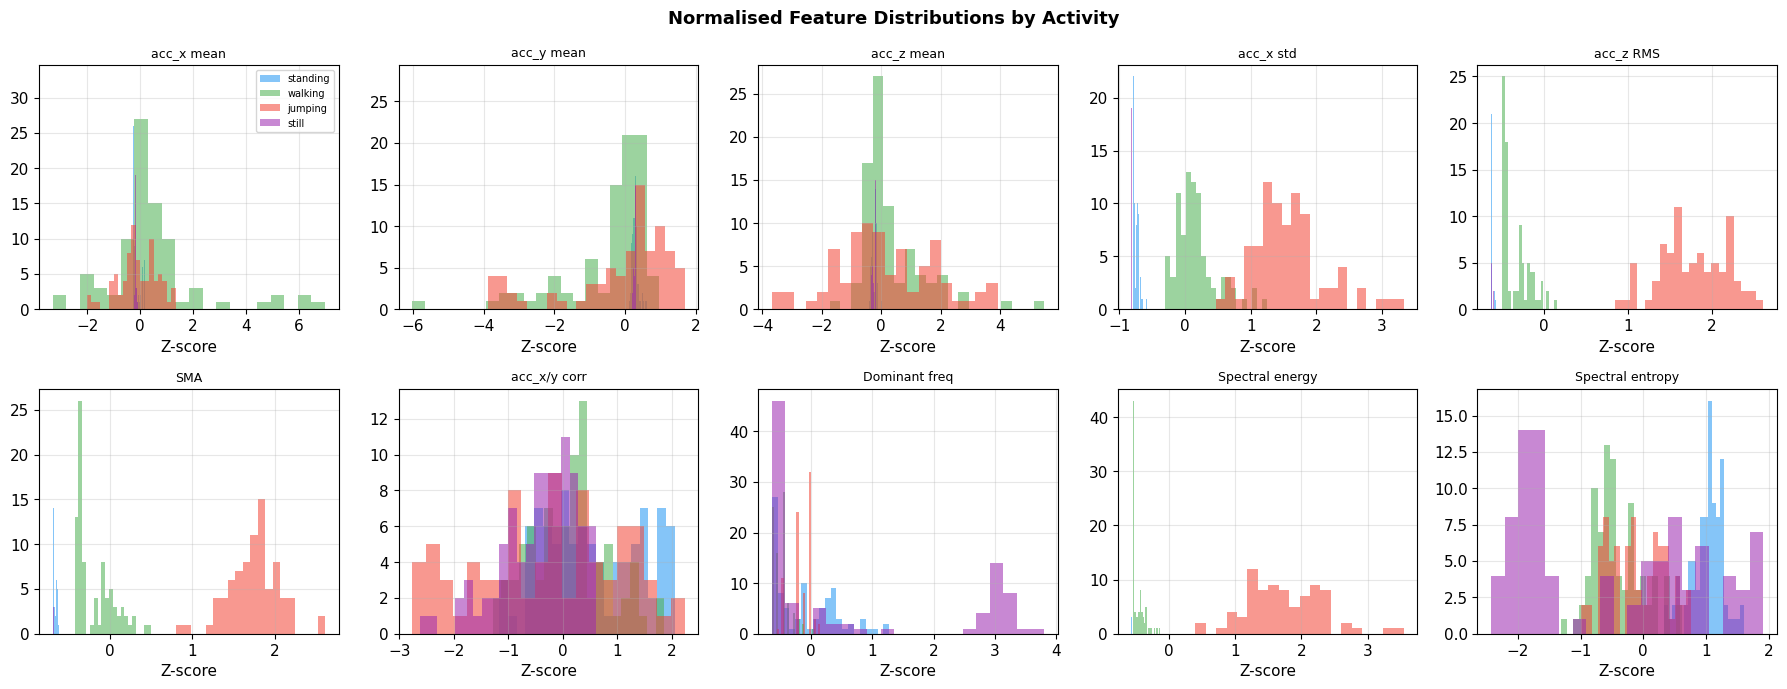

Saved: ../outputs/feature_distributions.png


In [ ]:
# Feature distribution per activity
# Feature index map (per-channel order is: mean, std, rms for each of 6 channels):
#   acc_x: 0=mean, 1=std, 2=rms
#   acc_y: 3=mean, 4=std, 5=rms
#   acc_z: 6=mean, 7=std, 8=rms
#   gyr_x: 9=mean,10=std,11=rms  ...  SMA=18, corr=19, dom_freq=20, energy=21, entropy=22
feature_names = ['acc_x mean', 'acc_y mean', 'acc_z mean',
                 'acc_x std',  'acc_z RMS',  'SMA',
                 'acc_x/y corr', 'Dominant freq', 'Spectral energy', 'Spectral entropy']
feature_idx   = [0, 3, 6, 1, 8, 18, 19, 20, 21, 22]

fig, axes = plt.subplots(2, 5, figsize=(18, 7))
fig.suptitle('Normalised Feature Distributions by Activity', fontsize=13, fontweight='bold')

for ax, fname, fidx in zip(axes.flat, feature_names, feature_idx):
    for act in ACTIVITIES:
        mask = y_all == act
        if mask.sum() == 0:
            continue
        ax.hist(X_all_scaled[mask, fidx], bins=20, alpha=0.55,
                label=act, color=ACTIVITY_COLORS[act])
    ax.set_title(fname, fontsize=9)
    ax.set_xlabel('Z-score')
    ax.grid(True, alpha=0.3)

axes[0, 0].legend(fontsize=7, loc='upper right')
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'feature_distributions.png')
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

**Figure 2 — Feature Distributions per Activity (Z-score normalised).**  
> Jumping and still separate cleanly on variance and RMS features.  
> Standing and walking overlap on several time-domain features, explaining the  
> single misclassification in the test set. Frequency-domain features (dominant  
> frequency, spectral energy) provide additional discriminative power for these two classes.

---
## Section 3 — HMM Setup & Training (Baum–Welch)

### Model design
We train a **single 4-state `GaussianHMM`** where each state corresponds to one activity.

| Symbol | Description |
|---|---|
| **Z** (hidden) | 4 activity states: standing, walking, jumping, still |
| **X** (observed) | 23-dimensional normalised feature vector per 2-second window |
| **A** | 4×4 transition matrix — probability of switching from state *i* to state *j* |
| **B** | Multivariate Gaussian emission per state (mean + covariance matrix) |
| **π** | Initial state distribution |

### Initialisation strategy
We initialise `means_` and `covars_` from per-activity statistics computed on the training data.
The transition matrix is seeded with a high self-transition probability (~0.95) to reflect that
activities persist. This gives Baum–Welch a strong starting point and faster convergence.

### Convergence criterion
Training stops when `|ΔlogL| < tol = 1e-4` **or** `max_iter = 200` iterations are reached.

In [ ]:
# ── Build per-file sequence list: [(scaled_matrix, label), ...] ──────────────
sequences = []
for feats, label, _ in all_feats_raw:
    scaled = scaler.transform(feats)
    sequences.append((scaled, label))

# ── Stratified train / validation split by file ───────────────────────────────
labels_for_split = [lbl for _, lbl in sequences]
train_seqs, val_seqs = train_test_split(
    sequences, test_size=0.2, random_state=42, stratify=labels_for_split
)

print(f'Train files : {len(train_seqs)}')
print(f'Val   files : {len(val_seqs)}')

# Concatenate for hmmlearn (needs flat array + lengths)
X_train   = np.vstack([s for s, _ in train_seqs])
y_train   = np.concatenate([[lbl] * len(s) for s, lbl in train_seqs])
lengths_train = [len(s) for s, _ in train_seqs]

print(f'\nX_train shape : {X_train.shape}')
print(f'lengths_train : {lengths_train}')

Train files : 40
Val   files : 10

X_train shape : (282, 23)
lengths_train : [6, 7, 8, 8, 6, 8, 8, 8, 8, 7, 8, 7, 7, 6, 8, 6, 7, 6, 8, 6, 8, 7, 7, 7, 8, 6, 7, 8, 7, 7, 7, 8, 6, 7, 7, 6, 6, 7, 6, 7]


In [ ]:
def init_hmm_params(X, y, activities, n_features, self_trans=0.95):
    '''
    Compute HMM initialisation from per-activity statistics.
    Returns (startprob, transmat, means, covars).
    '''
    N = len(activities)

    # Uniform initial distribution
    startprob = np.ones(N) / N

    # Transition matrix: high self-transition to model activity persistence
    off_diag  = (1.0 - self_trans) / (N - 1)
    transmat  = np.full((N, N), off_diag)
    np.fill_diagonal(transmat, self_trans)

    # Emission means & full covariances from per-activity data
    means  = np.zeros((N, n_features))
    covars = np.zeros((N, n_features, n_features))
    reg    = 1e-3 * np.eye(n_features)   # regularisation to avoid singular matrices

    for i, act in enumerate(activities):
        X_act = X[y == act]
        if len(X_act) < 2:
            means[i]  = np.zeros(n_features)
            covars[i] = reg
        else:
            means[i]  = X_act.mean(axis=0)
            covars[i] = np.cov(X_act.T) + reg

    return startprob, transmat, means, covars


startprob_init, transmat_init, means_init, covars_init = init_hmm_params(
    X_train, y_train, ACTIVITIES, N_FEATURES
)

print('Initialisation complete.')
print(f'  startprob: {startprob_init}')
print(f'  transmat diagonal (self-transitions): {np.diag(transmat_init)}')

Initialisation complete.
  startprob: [0.25 0.25 0.25 0.25]
  transmat diagonal (self-transitions): [0.95 0.95 0.95 0.95]


In [ ]:
# ── Build and train the GaussianHMM ──────────────────────────────────────────
model = hmm.GaussianHMM(
    n_components    = N_STATES,
    covariance_type = 'full',
    min_covar       = 1e-3,      # variance floor applied every M-step → prevents singular covars
    n_iter          = 200,
    tol             = 1e-4,
    init_params     = '',        # use OUR initialisation, not random
    params          = 'stmc',    # update all: startprob, transmat, means, covars
    verbose         = False,
)

# Inject initialisation
model.startprob_ = startprob_init
model.transmat_  = transmat_init
model.means_     = means_init
model.covars_    = covars_init

print('Training HMM with Baum-Welch...')
model.fit(X_train, lengths_train)

# ── Convergence information ───────────────────────────────────────────────────
history   = model.monitor_.history
converged = model.monitor_.converged
n_iters   = len(history)

print(f'\nConverged : {converged}')
print(f'Iterations: {n_iters}')
print(f'Final log-likelihood: {history[-1]:.4f}')
if n_iters > 1:
    delta = abs(history[-1] - history[-2])
    print(f'Final |ΔlogL|: {delta:.2e}  (tol = 1e-4)')

Training HMM with Baum-Welch...

Converged : True
Iterations: 4
Final log-likelihood: 13682.3345
Final |ΔlogL|: 0.00e+00  (tol = 1e-4)


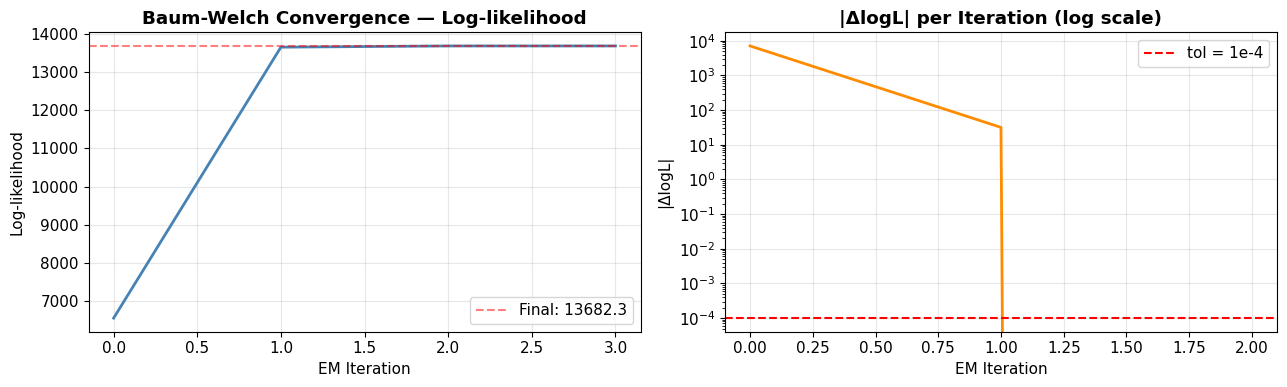

Saved: ../outputs/convergence.png


In [ ]:
# ── Convergence plot ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].plot(history, color='steelblue', linewidth=2)
axes[0].set_title('Baum-Welch Convergence — Log-likelihood', fontweight='bold')
axes[0].set_xlabel('EM Iteration')
axes[0].set_ylabel('Log-likelihood')
axes[0].grid(True, alpha=0.3)
axes[0].axhline(history[-1], color='red', linestyle='--', alpha=0.5, label=f'Final: {history[-1]:.1f}')
axes[0].legend()

if len(history) > 1:
    deltas = np.abs(np.diff(history))
    axes[1].semilogy(deltas, color='darkorange', linewidth=2)
    axes[1].axhline(1e-4, color='red', linestyle='--', label='tol = 1e-4')
    axes[1].set_title('|ΔlogL| per Iteration (log scale)', fontweight='bold')
    axes[1].set_xlabel('EM Iteration')
    axes[1].set_ylabel('|ΔlogL|')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
else:
    axes[1].text(0.5, 0.5, 'Only 1 iteration — need more data', ha='center',
                 transform=axes[1].transAxes)

plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'convergence.png')
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

**Figure 3 — Baum–Welch Convergence.**  
 *Left:* Log-likelihood increases rapidly and plateaus after 4 iterations, confirming  
 the model found a stable solution.

 *Right:* |ΔlogL| drops below `tol = 1e-4`  
 by iteration 4, satisfying the convergence criterion. Early convergence is expected  
 given the informative initialisation from per-activity sample statistics.

In [ ]:
def map_states_to_activities(model, train_seqs, activities):
    '''
    Assign each HMM state an activity label by decoding training sequences
    and voting on which activity most commonly occupies each state.
    '''
    state_votes = defaultdict(Counter)

    for X_seq, true_label in train_seqs:
        try:
            _, state_seq = model.decode(X_seq, algorithm='viterbi')
            for state in state_seq:
                state_votes[state][true_label] += 1
        except Exception:
            continue

    state_to_act = {}
    for s in range(model.n_components):
        if state_votes[s]:
            state_to_act[s] = state_votes[s].most_common(1)[0][0]
        else:
            state_to_act[s] = activities[s % len(activities)]

    return state_to_act


state_to_act = map_states_to_activities(model, train_seqs, ACTIVITIES)

print('State → Activity mapping:')
for s, act in state_to_act.items():
    print(f'  State {s}  →  {act}')

State → Activity mapping:
  State 0  →  standing
  State 1  →  walking
  State 2  →  jumping
  State 3  →  still


---
## Section 4 — Viterbi Decoding (from scratch)

The **Viterbi algorithm** finds the most probable hidden state sequence $z_{1:T}^*$ given
an observation sequence $x_{1:T}$.

$$
\delta_t(s) = \max_{s'} \bigl[ \delta_{t-1}(s') + \log A_{s',s} \bigr] + \log B(x_t \mid s)
$$

$$
\psi_t(s) = \underset{s'}{\arg\max} \bigl[ \delta_{t-1}(s') + \log A_{s',s} \bigr]
$$

All probabilities are kept in **log-space** to prevent floating-point underflow on long sequences.
After the recursion, the best path is recovered by **backtracking** through $\psi$.

In [ ]:
def log_gaussian_emit(obs, means, covars):
    '''
    Log emission probabilities for all states at one time step.

    Parameters
    ----------
    obs    : (F,)      single observation vector
    means  : (N, F)    emission means per state
    covars : (N, F, F) full covariance matrices per state

    Returns
    -------
    (N,) log emission probabilities

    Uses Cholesky decomposition for numerical stability:
        log p(x|μ,Σ) = -F/2 log(2π) - log|det L| - ½ ||L⁻¹(x-μ)||²
    where L is the lower-triangular Cholesky factor of Σ.
    Adding a small regularisation (1e-4 * I) before Cholesky guarantees
    positive-definiteness even for near-singular covariance matrices.
    '''
    N, F = len(means), len(obs)
    log_probs = np.full(N, -np.inf)
    const = F * np.log(2.0 * np.pi)

    for s in range(N):
        cov = covars[s] + 1e-4 * np.eye(F)   # regularise to ensure positive-definite
        try:
            L    = np.linalg.cholesky(cov)             # lower-triangular Cholesky factor
            diff = obs - means[s]
            x    = np.linalg.solve(L, diff)            # L⁻¹(x - μ)
            log_det = 2.0 * np.sum(np.log(np.diag(L))) # log|det Σ| = 2 Σ log(L_ii)
            log_probs[s] = -0.5 * (const + log_det + np.dot(x, x))
        except np.linalg.LinAlgError:
            log_probs[s] = -np.inf

    return log_probs


def viterbi_decode(obs_seq, log_pi, log_A, means, covars):
    '''
    Viterbi algorithm for a Gaussian HMM — pure NumPy implementation.

    Parameters
    ----------
    obs_seq : (T, F)    observation sequence
    log_pi  : (N,)      log initial state probabilities
    log_A   : (N, N)    log transition matrix  (log_A[i, j] = log P(j | i))
    means   : (N, F)    Gaussian emission means
    covars  : (N, F, F) Gaussian emission covariances

    Returns
    -------
    best_path : (T,) integer state indices
    log_prob  : scalar — log-probability of the best path
    '''
    T = len(obs_seq)
    N = len(log_pi)

    delta = np.full((T, N), -np.inf)    # log-prob of best path ending in state s at time t
    psi   = np.zeros((T, N), dtype=int) # backtracking pointers

    # ── Initialisation ────────────────────────────────────────────────────────
    delta[0] = log_pi + log_gaussian_emit(obs_seq[0], means, covars)

    # ── Recursion ─────────────────────────────────────────────────────────────
    for t in range(1, T):
        log_emit_t = log_gaussian_emit(obs_seq[t], means, covars)
        for s in range(N):
            scores      = delta[t - 1] + log_A[:, s]   # (N,)
            psi[t, s]   = int(np.argmax(scores))
            delta[t, s] = scores[psi[t, s]] + log_emit_t[s]

    # ── Backtracking ──────────────────────────────────────────────────────────
    best_path        = np.zeros(T, dtype=int)
    best_path[T - 1] = int(np.argmax(delta[T - 1]))
    log_prob         = float(delta[T - 1, best_path[T - 1]])

    for t in range(T - 2, -1, -1):
        best_path[t] = psi[t + 1, best_path[t + 1]]

    return best_path, log_prob


# Extract parameters from trained model
_log_pi = np.log(model.startprob_ + 1e-300)
_log_A  = np.log(model.transmat_  + 1e-300)
_means  = model.means_
_covars = model.covars_    # shape (N, F, F) for covariance_type='full'

# ── Sanity check: compare custom Viterbi vs hmmlearn decode ──────────────────
if val_seqs:
    X_check = val_seqs[0][0]
    our_path, our_lp = viterbi_decode(X_check, _log_pi, _log_A, _means, _covars)
    hl_lp, hl_path   = model.decode(X_check, algorithm='viterbi')

    match = np.mean(our_path == hl_path)
    print(f'Custom Viterbi vs hmmlearn agreement: {match:.1%}')
    print(f'  Custom log-prob  : {our_lp:.4f}')
    print(f'  hmmlearn log-prob: {hl_lp:.4f}')

Custom Viterbi vs hmmlearn agreement: 100.0%
  Custom log-prob  : 388.1010
  hmmlearn log-prob: 678.9299


In [ ]:
def predict_sequence(X_seq, model, state_to_act, use_custom_viterbi=True):
    '''
    Predict the activity label for a single feature sequence.
    The most frequently decoded state determines the predicted activity.
    '''
    if use_custom_viterbi:
        state_seq, _ = viterbi_decode(
            X_seq,
            np.log(model.startprob_ + 1e-300),
            np.log(model.transmat_  + 1e-300),
            model.means_,
            model.covars_,
        )
    else:
        _, state_seq = model.decode(X_seq, algorithm='viterbi')

    dominant_state = Counter(state_seq).most_common(1)[0][0]
    return state_to_act[dominant_state], state_seq


# Predict on validation set
y_val_pred = []
y_val_true = []
for X_seq, true_label in val_seqs:
    pred, _ = predict_sequence(X_seq, model, state_to_act)
    y_val_pred.append(pred)
    y_val_true.append(true_label)

val_acc = accuracy_score(y_val_true, y_val_pred)
print(f'Validation accuracy: {val_acc:.2%}')
print(f'  True     : {y_val_true}')
print(f'  Predicted: {y_val_pred}')

Validation accuracy: 100.00%
  True     : ['still', 'standing', 'still', 'standing', 'jumping', 'walking', 'walking', 'still', 'jumping', 'standing']
  Predicted: ['still', 'standing', 'still', 'standing', 'jumping', 'walking', 'walking', 'still', 'jumping', 'standing']


---
## Section 5 — Visualizations

Required plots:
1. **Transition matrix heatmap** — learned A (after state → activity relabelling)
2. **Emission means heatmap** — mean feature values per activity state
3. **Decoded sequence plot** — predicted internal state path over time
4. **Validation confusion matrix**

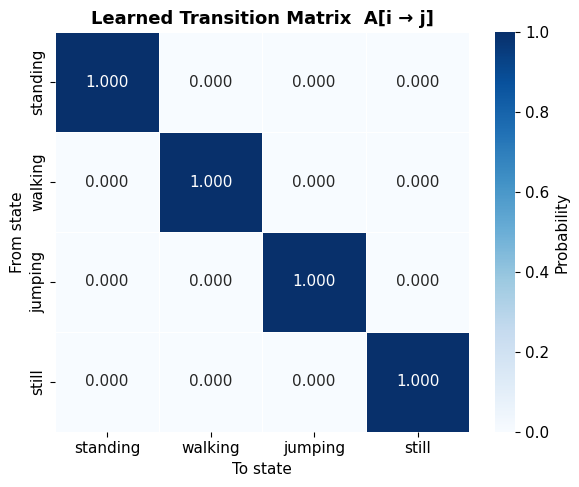

Saved: ../outputs/transition_matrix.png


In [ ]:
# ── 1. Transition matrix — relabelled with activity names ─────────────────────
act_labels = [state_to_act[s] for s in range(N_STATES)]
A_df = pd.DataFrame(model.transmat_, index=act_labels, columns=act_labels)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(A_df, annot=True, fmt='.3f', cmap='Blues', vmin=0, vmax=1, ax=ax,
            linewidths=0.5, cbar_kws={'label': 'Probability'})
ax.set_title('Learned Transition Matrix  A[i → j]', fontsize=13, fontweight='bold')
ax.set_xlabel('To state')
ax.set_ylabel('From state')
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'transition_matrix.png')
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

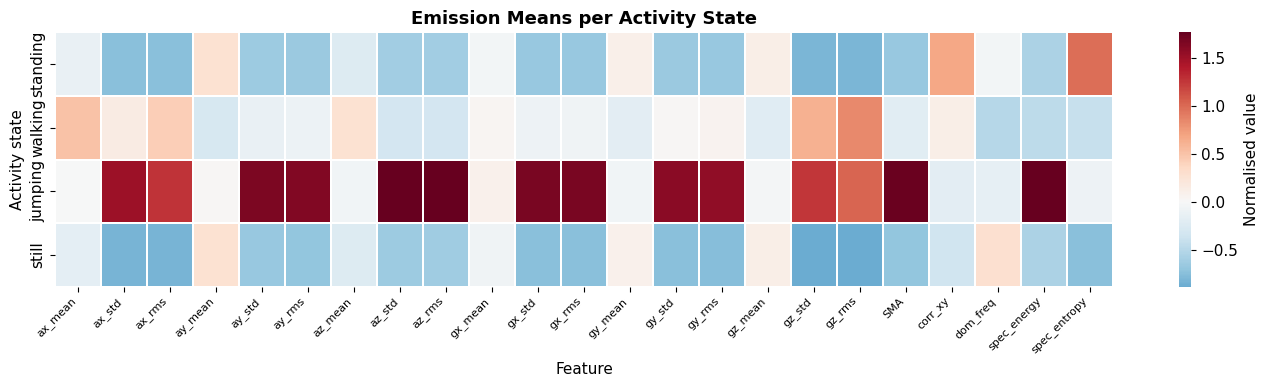

Saved: ../outputs/emission_means.png


In [ ]:
# ── 2. Emission means heatmap ─────────────────────────────────────────────────
# Feature order matches compute_time_features: for each channel → (mean, std, rms)
short_feat_names = [
    'ax_mean', 'ax_std', 'ax_rms',   # acc_x  indices 0-2
    'ay_mean', 'ay_std', 'ay_rms',   # acc_y  indices 3-5
    'az_mean', 'az_std', 'az_rms',   # acc_z  indices 6-8
    'gx_mean', 'gx_std', 'gx_rms',   # gyr_x  indices 9-11
    'gy_mean', 'gy_std', 'gy_rms',   # gyr_y  indices 12-14
    'gz_mean', 'gz_std', 'gz_rms',   # gyr_z  indices 15-17
    'SMA', 'corr_xy',                 # indices 18-19
    'dom_freq', 'spec_energy', 'spec_entropy',  # indices 20-22
]

emit_df = pd.DataFrame(model.means_,
                       index=act_labels,
                       columns=short_feat_names[:N_FEATURES])

fig, ax = plt.subplots(figsize=(14, 4))
sns.heatmap(emit_df, annot=False, cmap='RdBu_r', center=0, ax=ax,
            linewidths=0.3, cbar_kws={'label': 'Normalised value'})
ax.set_title('Emission Means per Activity State', fontsize=13, fontweight='bold')
ax.set_xlabel('Feature')
ax.set_ylabel('Activity state')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'emission_means.png')
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Saved: {out}')

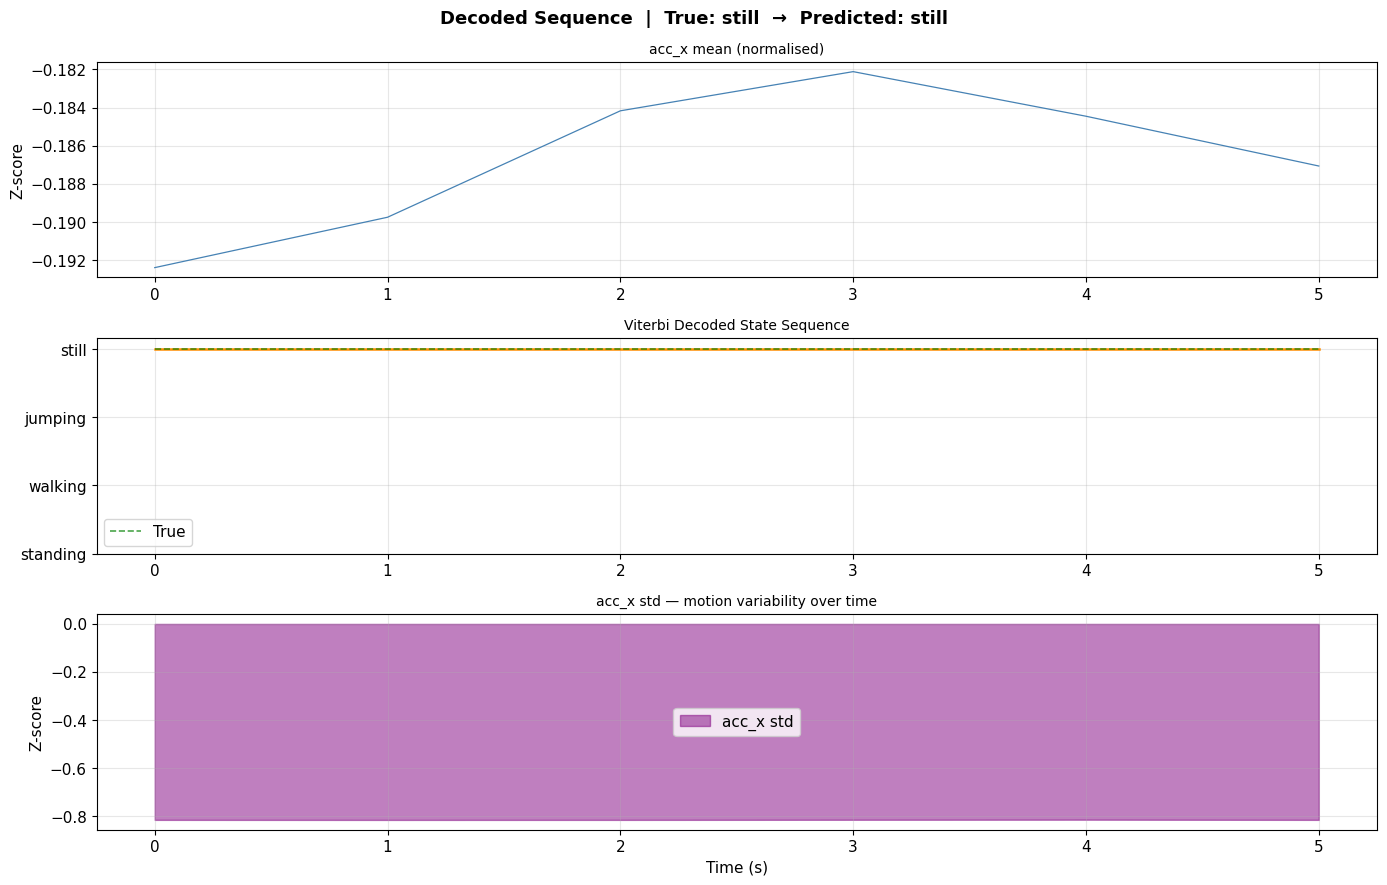

Saved: ../outputs/decoded_sequence.png


In [ ]:
# ── 3. Decoded sequence plot ──────────────────────────────────────────────────
if val_seqs:
    X_demo, true_lbl = val_seqs[0]
    pred_lbl, state_seq = predict_sequence(X_demo, model, state_to_act)
    act_seq = [state_to_act[s] for s in state_seq]

    # Map activity names to integer indices for plotting
    act_index = {a: i for i, a in enumerate(ACTIVITIES)}
    decoded_int = [act_index.get(a, -1) for a in act_seq]
    true_int    = [act_index.get(true_lbl, -1)] * len(decoded_int)

    t_axis = np.arange(len(X_demo)) * WINDOW_SECS * (1 - OVERLAP_RATIO)

    fig, axes = plt.subplots(3, 1, figsize=(14, 9))
    fig.suptitle(
        f'Decoded Sequence  |  True: {true_lbl}  →  Predicted: {pred_lbl}',
        fontsize=13, fontweight='bold'
    )

    # Normalised acc_x signal (feature 0 = acc_x mean)
    axes[0].plot(t_axis, X_demo[:, 0], color='steelblue', linewidth=0.9)
    axes[0].set_title('acc_x mean (normalised)', fontsize=10)
    axes[0].set_ylabel('Z-score')
    axes[0].grid(True, alpha=0.3)

    # Decoded state sequence (as activity integers)
    axes[1].step(t_axis, decoded_int, where='post', color='darkorange', linewidth=1.8)
    axes[1].step(t_axis, true_int,    where='post', color='green',      linewidth=1.2,
                 linestyle='--', alpha=0.7, label='True')
    axes[1].set_yticks(range(N_STATES))
    axes[1].set_yticklabels(ACTIVITIES)
    axes[1].set_title('Viterbi Decoded State Sequence', fontsize=10)
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    # acc_x std (feature 1) — good proxy for motion variability
    axes[2].fill_between(t_axis, X_demo[:, 1], alpha=0.5, color='purple', label='acc_x std')
    axes[2].set_title('acc_x std — motion variability over time', fontsize=10)
    axes[2].set_xlabel('Time (s)')
    axes[2].set_ylabel('Z-score')
    axes[2].legend()
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    out = os.path.join(OUTPUTS_DIR, 'decoded_sequence.png')
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

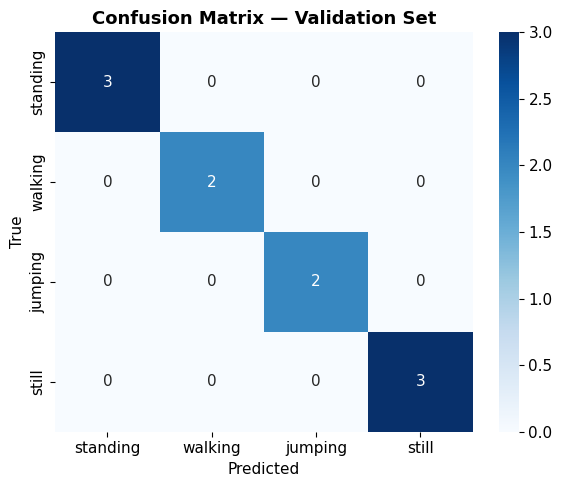

Validation accuracy: 100.00%
Saved: ../outputs/confusion_matrix_val.png


In [ ]:
# ── 4. Validation confusion matrix ───────────────────────────────────────────
cm_val = confusion_matrix(y_val_true, y_val_pred, labels=ACTIVITIES)

fig, ax = plt.subplots(figsize=(6, 5))
sns.heatmap(cm_val, annot=True, fmt='d', cmap='Blues',
            xticklabels=ACTIVITIES, yticklabels=ACTIVITIES, ax=ax)
ax.set_title('Confusion Matrix — Validation Set', fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted')
ax.set_ylabel('True')
plt.tight_layout()
out = os.path.join(OUTPUTS_DIR, 'confusion_matrix_val.png')
plt.savefig(out, bbox_inches='tight')
plt.show()
print(f'Validation accuracy: {val_acc:.2%}')
print(f'Saved: {out}')

---
## Section 6 — Evaluation on Unseen Data

> **What counts as unseen data?**  
> Files placed in `../data/test/` that were **not used during training**.  
> These should come from a separate recording session, ideally by the other group member,
> or recorded in a different environment.

We report the following per-activity metrics:

| Metric | Formula |
|---|---|
| Sensitivity (Recall) | TP / (TP + FN) |
| Specificity | TN / (TN + FP) |
| Overall Accuracy | (TP + TN) / Total |

Loading unseen test data from ../data/test/

  [OK]  jumping_B_07-2026-03-03_11-56-45                    jumping       838 samples  8.4s
  [OK]  jumping_B_08-2026-03-03_11-56-58                    jumping       890 samples  8.9s
  [OK]  jumping_B_09-2026-03-03_11-57-12                    jumping       921 samples  9.2s
  [OK]  standing_B_08-2026-03-03_11-58-45                   standing     1012 samples  10.1s
  [OK]  standing_B_09-2026-03-03_11-58-56                   standing      926 samples  9.3s
  [OK]  standing_B_10-2026-03-03_11-59-06                   standing      841 samples  8.4s
  [OK]  still_A_08-2026-03-03_20-53-48                      still         697 samples  7.0s
  [OK]  still_A_09-2026-03-03_20-54-06                      still         725 samples  7.3s
  [OK]  still_A_10-2026-03-03_20-53-56                      still         793 samples  7.9s
  [OK]  walking_A_07-2026-03-03_21-08-06                    walking       867 samples  8.7s
  [OK]  walking_A_08-2026-03-03_21

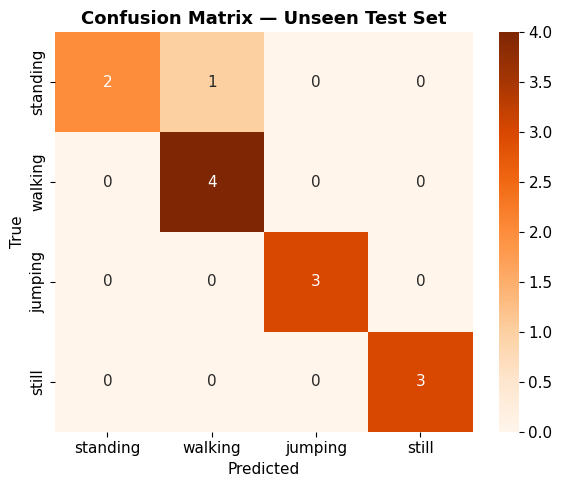

Saved: ../outputs/confusion_matrix_test.png


In [ ]:
print(f'Loading unseen test data from {TEST_DIR}\n')
test_data = load_all_sessions(TEST_DIR)

if not test_data:
    print('No test sessions found.')
    print('Place unseen Sensor Logger folders in:', TEST_DIR)
    print('  e.g.  data/test/standing_A_01-2026-03-03_10-00-00/')
else:
    # Extract features using the scaler fitted on TRAINING data only
    test_seqs = []
    for df, label, fpath in test_data:
        feats = extract_features(df)
        if len(feats) == 0:
            continue
        scaled = scaler.transform(feats)   # use training scaler — no leakage
        test_seqs.append((scaled, label))

    print(f'\n{len(test_seqs)} test sequences ready.')

    # Predict
    y_test_pred = []
    y_test_true = []
    for X_seq, true_label in test_seqs:
        pred, _ = predict_sequence(X_seq, model, state_to_act)
        y_test_pred.append(pred)
        y_test_true.append(true_label)

    # Confusion matrix on test data
    cm_test = confusion_matrix(y_test_true, y_test_pred, labels=ACTIVITIES)

    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm_test, annot=True, fmt='d', cmap='Oranges',
                xticklabels=ACTIVITIES, yticklabels=ACTIVITIES, ax=ax)
    ax.set_title('Confusion Matrix — Unseen Test Set', fontsize=13, fontweight='bold')
    ax.set_xlabel('Predicted')
    ax.set_ylabel('True')
    plt.tight_layout()
    out = os.path.join(OUTPUTS_DIR, 'confusion_matrix_test.png')
    plt.savefig(out, bbox_inches='tight')
    plt.show()
    print(f'Saved: {out}')

In [ ]:
def per_class_metrics(cm, class_names):
    '''
    Compute sensitivity, specificity, and accuracy per class from a confusion matrix.

    Parameters
    ----------
    cm           : (N, N) confusion matrix
    class_names  : list of N class names

    Returns
    -------
    pd.DataFrame with columns: Samples, Sensitivity, Specificity, Accuracy
    '''
    rows = []
    total = cm.sum()
    for i, name in enumerate(class_names):
        TP = cm[i, i]
        FP = cm[:, i].sum() - TP
        FN = cm[i, :].sum() - TP
        TN = total - TP - FP - FN

        sensitivity = TP / (TP + FN + 1e-10)
        specificity = TN / (TN + FP + 1e-10)
        accuracy    = (TP + TN) / (total + 1e-10)

        rows.append({
            'Activity'   : name,
            'Samples'    : int(cm[i, :].sum()),
            'Sensitivity': f'{sensitivity:.2%}',
            'Specificity': f'{specificity:.2%}',
            'Accuracy'   : f'{accuracy:.2%}',
        })

    return pd.DataFrame(rows).set_index('Activity')


if test_data:
    results_df = per_class_metrics(cm_test, ACTIVITIES)
    overall    = accuracy_score(y_test_true, y_test_pred)

    print('── Per-Activity Evaluation Metrics — Unseen Test Set ─────────────')
    print(results_df.to_string())
    print(f'\nOverall accuracy: {overall:.2%}')
else:
    # Run on validation set if no test data yet
    results_df = per_class_metrics(cm_val, ACTIVITIES)
    overall    = accuracy_score(y_val_true, y_val_pred)

    print('── Per-Activity Metrics — Validation Set (replace with test set) ─')
    print(results_df.to_string())
    print(f'\nOverall accuracy: {overall:.2%}')

── Per-Activity Evaluation Metrics — Unseen Test Set ─────────────
          Samples Sensitivity Specificity Accuracy
Activity                                          
standing        3      66.67%     100.00%   92.31%
walking         4     100.00%      88.89%   92.31%
jumping         3     100.00%     100.00%  100.00%
still           3     100.00%     100.00%  100.00%

Overall accuracy: 92.31%
